# Week 5 – Deep Learning Application in Data Science

**Problem:** classify handwritten digits (0–9) using a PyTorch neural network on the public scikit-learn Digits dataset.

## 1. Imports and reproducibility
We fix random seeds so that the main experiment can be reproduced.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report, roc_auc_score

SEED = 42
random.seed(SEED)
numpy = np.random.seed(SEED)
torch.manual_seed(SEED)
print('PyTorch:', torch.__version__)

PyTorch: 2.10.0+cpu


## 2. Load and inspect the dataset

In [2]:
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)
print('Shape:', X.shape)
print('Classes:', np.unique(y))
print('Missing values:', np.isnan(X).sum())
print(pd.Series(y).value_counts().sort_index())

Shape: (1797, 64)
Classes: [0 1 2 3 4 5 6 7 8 9]
Missing values: 0
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


## 3. Train/validation/test split and standardization
A stratified 70/15/15 split is used. Standardization is fitted on the training set only to avoid leakage.

In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)
X_test_s = scaler.transform(X_test).astype(np.float32)
print(len(X_train), len(X_val), len(X_test))

1257 270 270


## 4. Neural-network architecture
The model uses dense layers with ReLU activation, Batch Normalization, Dropout, and a 10-unit output layer. Cross-entropy loss is used, so the final layer returns logits rather than applying softmax inside the model.

In [4]:
class DigitMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.30),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.net(x)

model = DigitMLP()
print(model)

DigitMLP(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)


## 5. Training loop with validation and early stopping
Adam is used with learning rate 1e-3 and weight decay 1e-4. The best validation-loss state is retained.

In [5]:
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_s), torch.tensor(y_train)),
    batch_size=32, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val_s), torch.tensor(y_val)),
    batch_size=128, shuffle=False
)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

def evaluate(loader):
    model.eval(); total_loss = 0.0; correct = 0; total = 0
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * len(yb)
            correct += (logits.argmax(1) == yb).sum().item()
            total += len(yb)
    return total_loss / total, correct / total

best_state = None
best_val_loss = float('inf')
wait = 0
patience = 12
history = []
for epoch in range(1, 101):
    model.train(); running_loss = 0.0; correct = 0; total = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(yb)
        correct += (logits.argmax(1) == yb).sum().item()
        total += len(yb)
    train_loss = running_loss / total
    train_acc = correct / total
    val_loss, val_acc = evaluate(val_loader)
    history.append([epoch, train_loss, train_acc, val_loss, val_acc])
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
    if wait >= patience:
        break
model.load_state_dict(best_state)
history_df = pd.DataFrame(history, columns=['epoch','train_loss','train_accuracy','val_loss','val_accuracy'])
history_df

,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,1.715217,0.564837,1.116101,0.814815
1,2,0.772435,0.850438,0.468928,0.877778
2,3,0.388461,0.899761,0.265487,0.929630
3,4,0.232373,0.941130,0.198484,0.955556
4,5,0.180227,0.954654,0.152665,0.955556
5,6,0.135600,0.967383,0.132801,0.955556
6,7,0.117907,0.966587,0.129310,0.959259
7,8,0.097328,0.976929,0.124711,0.959259
8,9,0.080889,0.980111,0.120792,0.974074
9,10,0.071934,0.981702,0.119134,0.970370


## 6. Evaluate on the held-out test set

In [6]:
model.eval()
with torch.no_grad():
    logits = model(torch.tensor(X_test_s))
    probs = torch.softmax(logits, dim=1).numpy()
    pred = logits.argmax(1).numpy()

accuracy = accuracy_score(y_test, pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, pred, average='weighted', zero_division=0)
roc_auc = roc_auc_score(y_test, probs, multi_class='ovr', average='weighted')
print('Accuracy:', round(accuracy, 4))
print('Weighted precision:', round(precision, 4))
print('Weighted recall:', round(recall, 4))
print('Weighted F1:', round(f1, 4))
print('Weighted ROC-AUC:', round(roc_auc, 4))
print(classification_report(y_test, pred))

Accuracy: 0.9889
Weighted precision: 0.9893
Weighted recall: 0.9889
Weighted F1: 0.9889
Weighted ROC-AUC: 0.9998
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.93      0.96      0.95        28
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        28
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        27
           6       1.00      1.00      1.00        27
           7       1.00      1.00      1.00        27
           8       1.00      0.92      0.96        26
           9       0.96      1.00      0.98        27

    accuracy                           0.99       270
   macro avg       0.99      0.99      0.99       270
weighted avg       0.99      0.99      0.99       270



## 7. Visualize learning behavior

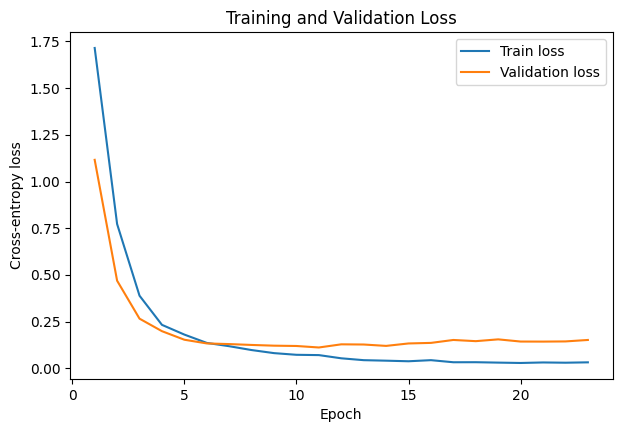

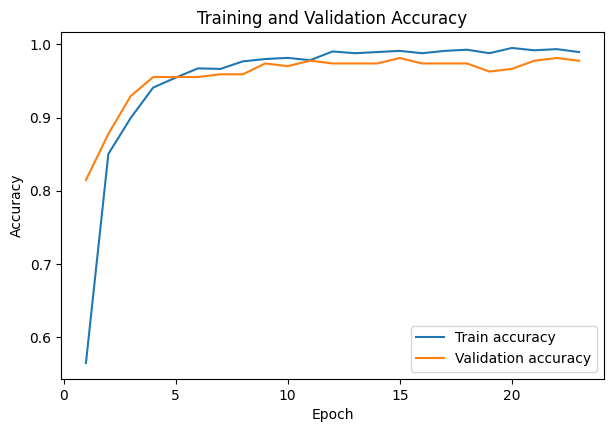

In [7]:
fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(history_df.epoch, history_df.train_loss, label='Train loss')
ax.plot(history_df.epoch, history_df.val_loss, label='Validation loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-entropy loss'); ax.set_title('Training and Validation Loss'); ax.legend(); plt.show()

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(history_df.epoch, history_df.train_accuracy, label='Train accuracy')
ax.plot(history_df.epoch, history_df.val_accuracy, label='Validation accuracy')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.set_title('Training and Validation Accuracy'); ax.legend(); plt.show()

## 8. Confusion matrix and example predictions

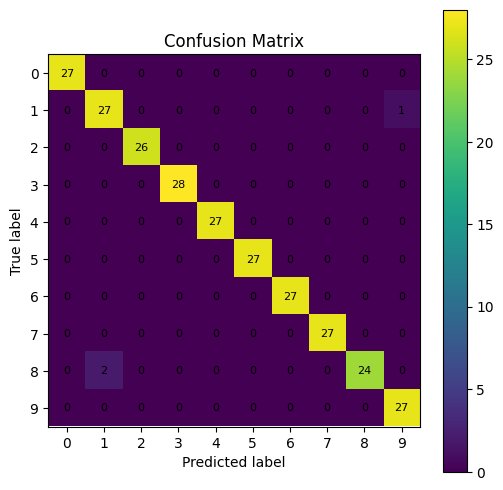

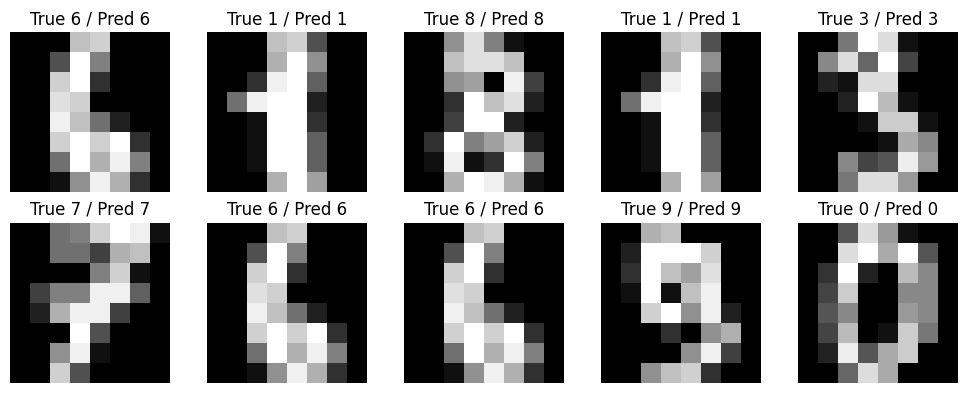

In [8]:
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(cm)
plt.colorbar(im, ax=ax)
ax.set_xlabel('Predicted label'); ax.set_ylabel('True label'); ax.set_title('Confusion Matrix')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=8)
plt.show()

fig, axes = plt.subplots(2,5, figsize=(10,4))
for ax, idx in zip(axes.ravel(), range(10)):
    ax.imshow(digits.images[y_test[idx]], cmap='gray')
    ax.set_title(f'True {y_test[idx]} / Pred {pred[idx]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 9. Five-fold cross-validation
A separate five-fold stratified experiment is included as a robustness check. Each fold repeats scaling and neural-network training from scratch.

In [9]:
def fit_fold(Xtr, ytr, Xv, yv, seed):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    sc = StandardScaler(); Xtr = sc.fit_transform(Xtr).astype(np.float32); Xv = sc.transform(Xv).astype(np.float32)
    net = DigitMLP()
    opt = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)
    dl = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(ytr)), batch_size=32, shuffle=True)
    for _ in range(20):
        net.train()
        for xb,yb in dl:
            opt.zero_grad(); loss = criterion(net(xb), yb); loss.backward(); opt.step()
    net.eval()
    with torch.no_grad(): pp = net(torch.tensor(Xv)).argmax(1).numpy()
    a,p,r,f = precision_recall_fscore_support(yv, pp, average='weighted', zero_division=0)
    return accuracy_score(yv, pp), p, r, f

fold_rows=[]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for fold,(tr,va) in enumerate(skf.split(X,y),1):
    a,p,r,f = fit_fold(X[tr], y[tr], X[va], y[va], 100+fold)
    fold_rows.append([fold,a,p,r,f])
cv_df = pd.DataFrame(fold_rows, columns=['fold','accuracy','weighted_precision','weighted_recall','weighted_f1'])
cv_df

,fold,accuracy,weighted_precision,weighted_recall,weighted_f1
0,1,0.972222,0.972222,0.972351,None
1,2,0.980556,0.980556,0.980592,None
2,3,0.972145,0.972145,0.972236,None
3,4,0.977716,0.977716,0.977404,None
4,5,0.988858,0.988858,0.988851,None


## 10. Conclusions
The model reaches high predictive performance on the held-out test data. The learning curves show fast convergence, while dropout, batch normalization, and weight decay reduce the risk of overfitting. Five-fold cross-validation gives a mean accuracy of about 97.8%, indicating good stability across splits. Limitations include the small 8×8 image resolution and the fact that a fully connected network does not explicitly exploit spatial structure; a CNN would be the natural next improvement.